# Notebook 6 - Noise, Errors & Quantum Information Measures

### Quantum Computing Education Series by Trinexis · Trinexis

**Thesis of the course:** *Indistinguishable alternatives interfere; probabilities are squared magnitudes of amplitudes.*

In Notebooks 3–4 we built the **density matrix** $\rho$ and the **Bloch Sphere**, and learned that **purity** and **coherence** drop when which-path information leaks to the environment. This notebook discusses the following:

- **Part A - Noise as dynamics.** Real qubits are not closed systems. Bit-flip, phase-flip, depolarizing, relaxation ($T_1$) and dephasing ($T_2$) are *completely positive trace-preserving (CPTP) maps* that **deform the Bloch sphere** in characteristic ways. We will *see* each one.
- **Part B - Information measures as diagnostics.** Purity, von Neumann entropy, relative entropy, fidelity, trace distance, coherence, mutual information, conditional entropy, entanglement entropy and the Holevo quantity are the *rulers* we use to read off exactly what the noise did.

> **The unifying picture:** A noise channel pushes the Bloch vector $\mathbf r$ inward / sideways / upward. Every information measure is, at heart, a *geometric readout* of where $\mathbf r$ (or the pair $\mathbf r_\rho, \mathbf r_\sigma$) sits in the sphere.

The SG-cascade spine returns at the end: **decoherence is just the dephasing channel acting on the spin density matrix**, and that is *why* a monitored which-path SG experiment loses its interference.


## 0 · Setup and the reusable toolkit

We carry forward the toolkit from Notebooks 3–4 **unchanged** (`rho_from_bloch`, `bloch_from_rho`, `purity`, …) and add a small set of new primitives: matrix functions via eigendecomposition (no SciPy - we keep the spectral relationship explicit), a Kraus-channel applier, and a Bloch-sphere renderer.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from numpy.linalg import eigh, eigvalsh

np.random.seed(42)               # reproducible in-class demonstrations
np.set_printoptions(precision=4, suppress=True)

# ---- Pauli matrices and basis kets -----------------------------------
I2 = np.eye(2, dtype=complex)
X  = np.array([[0, 1], [1, 0]], dtype=complex)
Y  = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z  = np.array([[1, 0], [0, -1]], dtype=complex)
PAULI = {'I': I2, 'X': X, 'Y': Y, 'Z': Z}

ket0 = np.array([[1], [0]], dtype=complex)
ket1 = np.array([[0], [1]], dtype=complex)
plus  = (ket0 + ket1) / np.sqrt(2)
minus = (ket0 - ket1) / np.sqrt(2)
print("Toolkit core loaded - Pauli matrices, computational and |±> kets ready.")

Toolkit core loaded - Pauli matrices, computational and |±> kets ready.


In [2]:
# ---- Carried forward from Notebooks 3-4 (unchanged) ------------------
def density_matrix_from_pure(psi):
    '''|psi><psi| from a column ket.'''
    psi = np.asarray(psi, dtype=complex).reshape(-1, 1)
    psi = psi / np.linalg.norm(psi)
    return psi @ psi.conj().T

def rho_from_bloch(r):
    '''rho = 1/2 (I + r.sigma) for r = (rx, ry, rz).'''
    rx, ry, rz = r
    return 0.5 * (I2 + rx*X + ry*Y + rz*Z)

def bloch_from_rho(rho):
    '''Inverse map: r_k = Tr(rho sigma_k).'''
    return np.array([np.real(np.trace(rho @ P)) for P in (X, Y, Z)])

def purity(rho):
    '''gamma = Tr(rho^2) in [1/d, 1].'''
    return float(np.real(np.trace(rho @ rho)))

def born_probs(rho, basis=(ket0, ket1)):
    '''Born-rule outcome probabilities in a given orthonormal basis.'''
    return np.array([float(np.real((b.conj().T @ rho @ b)[0, 0])) for b in basis])

print("Carried-forward toolkit ready: density_matrix_from_pure, rho_from_bloch,")
print("bloch_from_rho, purity, born_probs.")

Carried-forward toolkit ready: density_matrix_from_pure, rho_from_bloch,
bloch_from_rho, purity, born_probs.


In [3]:
# ---- NEW: matrix functions via eigendecomposition --------------------
def _spectral_apply(rho, f):
    '''Apply scalar function f to a Hermitian matrix via its spectrum.'''
    w, V = eigh((rho + rho.conj().T) / 2)      # symmetrise for safety
    return (V * f(w)) @ V.conj().T

def msqrt(rho):
    '''Matrix square root of a PSD Hermitian matrix.'''
    return _spectral_apply(rho, lambda w: np.sqrt(np.clip(w, 0, None)))

def mlog2(rho, eps=1e-12):
    '''Base-2 matrix logarithm; eigenvalues <= eps are mapped to log=0
    (the 0*log0 = 0 convention, applied at the operator level).'''
    def f(w):
        out = np.zeros_like(w)
        good = w > eps
        out[good] = np.log2(w[good])
        return out
    return _spectral_apply(rho, f)

def apply_kraus(rho, kraus):
    '''CPTP channel  rho -> sum_i K_i rho K_i^dagger.'''
    return sum(K @ rho @ K.conj().T for K in kraus)

def kraus_is_cptp(kraus, tol=1e-9):
    '''Check the completeness relation sum_i K_i^dagger K_i = I.'''
    S = sum(K.conj().T @ K for K in kraus)
    return np.allclose(S, I2, atol=tol)

print("New primitives ready: msqrt, mlog2, apply_kraus, kraus_is_cptp.")

New primitives ready: msqrt, mlog2, apply_kraus, kraus_is_cptp.


In [4]:
# ---- NEW: Bloch-sphere renderer ----------------------------------------
def _sphere_grid(n=40):
    u = np.linspace(0, 2*np.pi, n)
    v = np.linspace(0, np.pi, n)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    return xs, ys, zs

def draw_channel_image(ax, lam=(1, 1, 1), shift=(0, 0, 0), title="",
                       arrows=None):
    '''Show how the unit Bloch sphere maps to an ellipsoid under a
    qubit channel with Bloch action  r -> lam * r + shift.'''
    xs, ys, zs = _sphere_grid()
    # faint reference unit sphere
    ax.plot_wireframe(xs, ys, zs, color='lightgray', linewidth=0.3,
                      rstride=3, cstride=3, alpha=0.5)
    # image ellipsoid
    ex = lam[0]*xs + shift[0]
    ey = lam[1]*ys + shift[1]
    ez = lam[2]*zs + shift[2]
    ax.plot_surface(ex, ey, ez, color='tab:blue', alpha=0.35,
                    rstride=2, cstride=2, linewidth=0)
    # axes
    for vec, lab in [((1,0,0),'x'), ((0,1,0),'y'), ((0,0,1),'z')]:
        ax.quiver(0,0,0, *vec, color='k', linewidth=0.8, arrow_length_ratio=0.08)
        ax.text(vec[0]*1.25, vec[1]*1.25, vec[2]*1.25, lab, fontsize=9)
    if arrows:
        for r0, r1, c in arrows:
            ax.quiver(*r0, *(np.array(r1)-np.array(r0)), color=c, linewidth=2,
                      arrow_length_ratio=0.18)
    ax.set_xlim(-1.1,1.1); ax.set_ylim(-1.1,1.1); ax.set_zlim(-1.1,1.1)
    ax.set_box_aspect((1,1,1)); ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

print("Bloch-ball renderer ready: draw_channel_image.")

Bloch-ball renderer ready: draw_channel_image.


### A note on conventions

A single qubit state is fixed by its Bloch vector $\mathbf r=(r_x,r_y,r_z)$ through
$$\rho=\tfrac12\big(I+r_x X+r_y Y+r_z Z\big),\qquad |\mathbf r|\le 1.$$
Pure states live on the **surface** ($|\mathbf r|=1$), mixed states **inside**, and the **maximally mixed** state $I/2$ sits at the **centre** ($\mathbf r=0$). A useful identity we will lean on repeatedly:
$$\boxed{\;\operatorname{Tr}(\rho^2)=\tfrac12\big(1+|\mathbf r|^2\big)\;}$$
so **purity is literally the squared radius in the sphere**. Every channel below is most naturally read as *what it does to $\mathbf r$*.

# Part A - Noise channels as Bloch-sphere deformations

## A.1 · The language: Kraus operators

An isolated qubit evolves unitarily, $\rho\mapsto U\rho U^\dagger$ - a **rotation** of the Bloch ball (rigid, radius-preserving). A qubit coupled to an environment evolves by a more general **CPTP map**, which always admits a **Kraus (operator-sum) representation**
$$ E(\rho)=\sum_i K_i\,\rho\,K_i^\dagger,\qquad \sum_i K_i^\dagger K_i=I.$$
The completeness relation guarantees $\operatorname{Tr} E(\rho)=1$ (probability is conserved). Unlike a unitary, a general channel **shrinks** the Bloch Sphere - pure states are pushed inward, purity falls, information leaks out. Each channel below is given *both* as Kraus operators *and* as its action on $\mathbf r$; a quick numerical check confirms the two agree.

In [5]:
# Sanity check the machinery on a unitary (rotation) "channel":
psi = (ket0 + 1j*ket1)/np.sqrt(2)        # a point on the equator
rho = density_matrix_from_pure(psi)
print("Bloch vector r        :", bloch_from_rho(rho))
print("Purity  Tr(rho^2)     :", round(purity(rho), 4), " (pure -> 1)")
print("1/2(1+|r|^2)          :", round(0.5*(1+np.dot(bloch_from_rho(rho),
                                                      bloch_from_rho(rho))), 4))
# A Hadamard is a unitary 'channel' with a single Kraus operator K0 = H:
H = (X + Z)/np.sqrt(2)
print("H is CPTP (single K)? :", kraus_is_cptp([H]))
print("After H, r            :", bloch_from_rho(apply_kraus(rho, [H])))

Bloch vector r        : [0. 1. 0.]
Purity  Tr(rho^2)     : 1.0  (pure -> 1)
1/2(1+|r|^2)          : 1.0
H is CPTP (single K)? : True
After H, r            : [ 0. -1.  0.]


## A.2 · Bit-flip channel  $\ E_X$

With probability $p$ the qubit is hit by a Pauli $X$ (a $|0\rangle\!\leftrightarrow\!|1\rangle$ flip):
$$ E_X(\rho)=(1-p)\,\rho+p\,X\rho X,\qquad
K_0=\sqrt{1-p}\,I,\;\; K_1=\sqrt{p}\,X.$$
**Bloch action:** the $X$-axis is the flip axis and survives; the other two shrink,
$$r_x\mapsto r_x,\qquad r_y\mapsto(1-2p)\,r_y,\qquad r_z\mapsto(1-2p)\,r_z.$$
The ball squashes into an ellipsoid pinched along $y$ and $z$. At $p=\tfrac12$ it collapses to the $x$-axis segment.

In [6]:
def bit_flip_kraus(p):
    return [np.sqrt(1-p)*I2, np.sqrt(p)*X]

def bit_flip_bloch(r, p):
    return np.array([r[0], (1-2*p)*r[1], (1-2*p)*r[2]])

p = 0.25
r0 = np.array([0.0, 0.8, 0.5])                 # some mixed state
rho0 = rho_from_bloch(r0)
r_kraus = bloch_from_rho(apply_kraus(rho0, bit_flip_kraus(p)))
r_bloch = bit_flip_bloch(r0, p)
print("Kraus result  r' :", r_kraus)
print("Bloch formula r' :", r_bloch)
print("Agree?           :", np.allclose(r_kraus, r_bloch))
print("CPTP?            :", kraus_is_cptp(bit_flip_kraus(p)))

Kraus result  r' : [0.   0.4  0.25]
Bloch formula r' : [0.   0.4  0.25]
Agree?           : True
CPTP?            : True


## A.3 · Phase-flip channel  $E_Z$  (dephasing in the $Z$ basis)

With probability $p$ a Pauli $Z$ is applied - it does nothing to $|0\rangle,|1\rangle$ but flips the *relative phase* of any superposition:
$$ E_Z(\rho)=(1-p)\,\rho+p\,Z\rho Z,\qquad
K_0=\sqrt{1-p}\,I,\;\; K_1=\sqrt{p}\,Z.$$
**Bloch action:** the $Z$-axis survives, the equatorial plane shrinks,
$$r_x\mapsto(1-2p)\,r_x,\quad r_y\mapsto(1-2p)\,r_y,\quad r_z\mapsto r_z.$$
In matrix terms it **multiplies the off-diagonal elements** by $(1-2p)$:
$$\begin{pmatrix}\rho_{00}&\rho_{01}\\\rho_{10}&\rho_{11}\end{pmatrix}
\mapsto
\begin{pmatrix}\rho_{00}&(1-2p)\rho_{01}\\(1-2p)\rho_{10}&\rho_{11}\end{pmatrix}.$$
This is **pure decoherence**: the *populations* (diagonal, the $Z$-basis probabilities) are untouched, but the *coherences* (off-diagonal) bleed away. At $p=\tfrac12$ the state becomes diagonal - classical. **This is the heart of the SG which-path story** (revisited in §A.9).

In [7]:
def phase_flip_kraus(p):
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Z]

def phase_flip_bloch(r, p):
    return np.array([(1-2*p)*r[0], (1-2*p)*r[1], r[2]])

# |+> is maximally coherent in the Z basis: watch its coherence die.
rho_plus = density_matrix_from_pure(plus)
print("rho(|+>) =\n", np.real(rho_plus))
for p in [0.0, 0.25, 0.5]:
    rp = apply_kraus(rho_plus, phase_flip_kraus(p))
    print(f"\np={p}:  populations (diag) = {np.real(np.diag(rp))}, "
          f"coherence |rho01| = {abs(rp[0,1]):.3f},  r = {bloch_from_rho(rp)}")

rho(|+>) =
 [[0.5 0.5]
 [0.5 0.5]]

p=0.0:  populations (diag) = [0.5 0.5], coherence |rho01| = 0.500,  r = [1. 0. 0.]

p=0.25:  populations (diag) = [0.5 0.5], coherence |rho01| = 0.250,  r = [0.5 0.  0. ]

p=0.5:  populations (diag) = [0.5 0.5], coherence |rho01| = 0.000,  r = [0. 0. 0.]


## A.4 · Bit–phase-flip channel  $\ E_Y$

The third Pauli error, $K_0=\sqrt{1-p}\,I,\ K_1=\sqrt p\,Y$: a simultaneous bit-and-phase flip. By symmetry the $Y$-axis survives:
$$r_x\mapsto(1-2p)r_x,\quad r_y\mapsto r_y,\quad r_z\mapsto(1-2p)r_z.$$
Bit-flip, phase-flip and bit–phase-flip are the three **Pauli channels**: each preserves one axis and pinches the orthogonal plane.

In [8]:
def bit_phase_flip_kraus(p):
    return [np.sqrt(1-p)*I2, np.sqrt(p)*Y]

p = 0.3
r0 = np.array([0.6, 0.0, 0.7])
chk = bloch_from_rho(apply_kraus(rho_from_bloch(r0), bit_phase_flip_kraus(p)))
print("r' (Kraus) :", chk, "   ->  y-component preserved:", np.isclose(chk[1], r0[1]))

r' (Kraus) : [0.24 0.   0.28]    ->  y-component preserved: True


## A.5 · Depolarizing channel

With probability $p$ the qubit is thrown away and replaced by *complete ignorance* $I/2$:
$$ E_{\text{dep}}(\rho)=(1-p)\,\rho+p\,\tfrac{I}{2}.$$
An equivalent **Pauli-twirl** form spreads the error symmetrically over all three axes:
$$ E_{\text{dep}}(\rho)=\Big(1-\tfrac{3p}{4}\Big)\rho+\tfrac{p}{4}\big(X\rho X+Y\rho Y+Z\rho Z\big).$$
**Bloch action:** an **isotropic shrink** toward the centre,
$$\mathbf r\mapsto(1-p)\,\mathbf r.$$
The ball stays a ball but contracts uniformly; at $p=1$ everything collapses to $I/2$. This is the "worst-case, structureless" noise model used in error-correction thresholds.

In [9]:
def depolarizing_kraus(p):
    # symmetric Pauli form with this exact p convention
    return [np.sqrt(1 - 3*p/4)*I2, np.sqrt(p/4)*X,
            np.sqrt(p/4)*Y,        np.sqrt(p/4)*Z]

def depolarizing_bloch(r, p):
    return (1-p)*np.array(r)

p = 0.4
r0 = np.array([0.5, -0.4, 0.6])
rk = bloch_from_rho(apply_kraus(rho_from_bloch(r0), depolarizing_kraus(p)))
print("Kraus  r' :", rk)
print("Bloch  r' :", depolarizing_bloch(r0, p))
print("Agree?    :", np.allclose(rk, depolarizing_bloch(r0, p)),
      "| CPTP?", kraus_is_cptp(depolarizing_kraus(p)))

Kraus  r' : [ 0.3  -0.24  0.36]
Bloch  r' : [ 0.3  -0.24  0.36]
Agree?    : True | CPTP? True


## A.6 · Amplitude damping - **relaxation, the $T_1$ process**

Real qubits *lose energy*: an excited $|1\rangle$ decays to the ground state $|0\rangle$ (spontaneous emission). This is **not** symmetric - $|0\rangle$ and $|1\rangle$ are physically different (one is lower energy). With damping parameter $\gamma=1-e^{-t/T_1}$,
$$K_0=\begin{pmatrix}1&0\\0&\sqrt{1-\gamma}\end{pmatrix},\qquad
K_1=\begin{pmatrix}0&\sqrt{\gamma}\\0&0\end{pmatrix}.$$
$K_1$ is the literal "jump" $|1\rangle\to|0\rangle$. **Bloch action:**
$$r_x\mapsto\sqrt{1-\gamma}\,r_x,\quad r_y\mapsto\sqrt{1-\gamma}\,r_y,\quad
\boxed{\,r_z\mapsto(1-\gamma)\,r_z+\gamma\,}.$$
The decisive feature is the **$+\gamma$ shift**: the ball contracts toward the **north pole $|0\rangle$**, *not* the centre. The fixed point is $\mathbf r=(0,0,1)$ - at $t\to\infty$ ($\gamma\to1$) every state relaxes to $|0\rangle\langle0|$. This is why a qubit left alone "falls asleep" in its ground state.

In [10]:
def amplitude_damping_kraus(gamma):
    K0 = np.array([[1, 0], [0, np.sqrt(1-gamma)]], dtype=complex)
    K1 = np.array([[0, np.sqrt(gamma)], [0, 0]], dtype=complex)
    return [K0, K1]

def amplitude_damping_bloch(r, gamma):
    s = np.sqrt(1-gamma)
    return np.array([s*r[0], s*r[1], (1-gamma)*r[2] + gamma])

# Start in the excited state |1> and relax:
rho1 = density_matrix_from_pure(ket1)
print("Start |1>:  r =", bloch_from_rho(rho1), " population P(1) =",
      born_probs(rho1)[1])
for g in [0.0, 0.5, 0.9, 1.0]:
    rg = apply_kraus(rho1, amplitude_damping_kraus(g))
    print(f"gamma={g}:  r = {bloch_from_rho(rg)},  P(1) = {born_probs(rg)[1]:.3f}")
print("\nFixed point check (gamma=1 from any state):")
print(bloch_from_rho(apply_kraus(rho_from_bloch([0.4,-0.3,-0.5]),
                                 amplitude_damping_kraus(1.0))), "-> north pole |0>")

Start |1>:  r = [ 0.  0. -1.]  population P(1) = 1.0
gamma=0.0:  r = [ 0.  0. -1.],  P(1) = 1.000
gamma=0.5:  r = [0. 0. 0.],  P(1) = 0.500
gamma=0.9:  r = [0.  0.  0.8],  P(1) = 0.100
gamma=1.0:  r = [0. 0. 1.],  P(1) = 0.000

Fixed point check (gamma=1 from any state):
[0. 0. 1.] -> north pole |0>


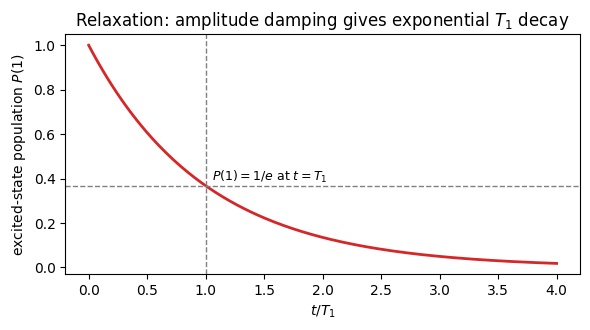

In [11]:
# Exponential T1 decay of the excited-state population P(1) = e^{-t/T1}
T1 = 1.0
t = np.linspace(0, 4*T1, 200)
gamma_t = 1 - np.exp(-t/T1)
P1 = np.array([born_probs(apply_kraus(rho1, amplitude_damping_kraus(g)))[1]
               for g in gamma_t])

fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(t/T1, P1, lw=2, color='tab:red')
ax.axhline(1/np.e, ls='--', color='gray', lw=1)
ax.axvline(1, ls='--', color='gray', lw=1)
ax.text(1.05, 1/np.e+0.02, r"$P(1)=1/e$ at $t=T_1$", fontsize=9)
ax.set_xlabel(r"$t / T_1$"); ax.set_ylabel("excited-state population $P(1)$")
ax.set_title("Relaxation: amplitude damping gives exponential $T_1$ decay")
plt.tight_layout(); plt.show()

## A.7 · Phase damping - **dephasing, the $T_2$ process**

Phase damping describes *loss of phase information with no energy loss* - elastic scattering, fluctuating fields. With $\lambda=1-e^{-t/T_2}$ (we use this scaling for the curve below),
$$K_0=\begin{pmatrix}1&0\\0&\sqrt{1-\lambda}\end{pmatrix},\qquad
K_1=\begin{pmatrix}0&0\\0&\sqrt{\lambda}\end{pmatrix}.$$
**Bloch action:** populations untouched, equator shrinks,
$$r_x\mapsto\sqrt{1-\lambda}\,r_x,\quad r_y\mapsto\sqrt{1-\lambda}\,r_y,\quad r_z\mapsto r_z.$$
This is **exactly the phase-flip channel in disguise**: setting $\sqrt{1-\lambda}=1-2p$ gives $p=\tfrac{1-\sqrt{1-\lambda}}{2}$. So "phase flip" and "phase damping" are the *same* CPTP map written with different Kraus operators - a clean illustration that **Kraus representations are not unique**.

**$T_1$ vs $T_2$ - the relationship every experimentalist quotes:**
$$\frac{1}{T_2}=\frac{1}{2T_1}+\frac{1}{T_\varphi}\quad\Longrightarrow\quad \boxed{T_2\le 2T_1}.$$
Relaxation ($T_1$, longitudinal, $r_z$) *also* destroys coherence, so it sets a ceiling on $T_2$; pure dephasing $T_\varphi$ ($r_x,r_y$ only) makes it worse.

In [12]:
def phase_damping_kraus(lam):
    K0 = np.array([[1, 0], [0, np.sqrt(1-lam)]], dtype=complex)
    K1 = np.array([[0, 0], [0, np.sqrt(lam)]],  dtype=complex)
    return [K0, K1]

# Show phase damping == phase flip for matched parameters
lam = 0.6
p_equiv = (1 - np.sqrt(1-lam))/2
r0 = np.array([0.7, 0.2, 0.5])
r_pd = bloch_from_rho(apply_kraus(rho_from_bloch(r0), phase_damping_kraus(lam)))
r_pf = bloch_from_rho(apply_kraus(rho_from_bloch(r0), phase_flip_kraus(p_equiv)))
print(f"lambda={lam}  <->  equivalent phase-flip p={p_equiv:.4f}")
print("phase-damping r' :", r_pd)
print("phase-flip   r' :", r_pf)
print("Same channel?   :", np.allclose(r_pd, r_pf))

lambda=0.6  <->  equivalent phase-flip p=0.1838
phase-damping r' : [0.4427 0.1265 0.5   ]
phase-flip   r' : [0.4427 0.1265 0.5   ]
Same channel?   : True


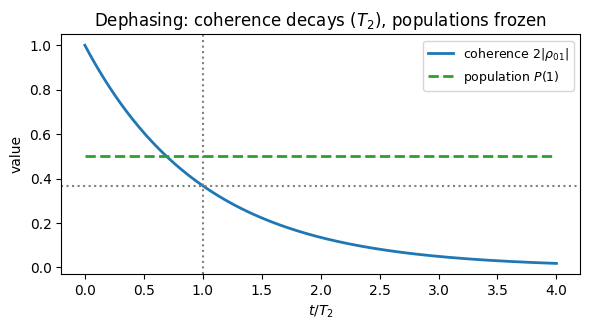

In [13]:
# Coherence |rho01| decays as e^{-t/T2}; population P(1) holds flat.
T2 = 1.0
t = np.linspace(0, 4*T2, 200)
lam_t = 1 - np.exp(-2*t/T2)              # |rho01| ~ e^{-t/T2}  (since ~ sqrt(1-lam))
coh = np.array([abs(apply_kraus(rho_plus, phase_damping_kraus(l))[0,1])
                for l in lam_t])
pop = np.array([born_probs(apply_kraus(rho_plus, phase_damping_kraus(l)))[1]
                for l in lam_t])

fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(t/T2, 2*coh, lw=2, color='tab:blue', label=r"coherence $2|\rho_{01}|$")
ax.plot(t/T2, pop,   lw=2, color='tab:green', ls='--', label="population $P(1)$")
ax.axhline(1/np.e, ls=':', color='gray'); ax.axvline(1, ls=':', color='gray')
ax.set_xlabel(r"$t/T_2$"); ax.set_ylabel("value")
ax.set_title("Dephasing: coherence decays ($T_2$), populations frozen")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

## A.8 · One picture: the five deformations side by side

Read the gallery as *geometry of error*. Pauli channels pinch a plane; depolarizing shrinks uniformly; **amplitude damping is the only one whose ellipsoid drifts off-centre** (toward $|0\rangle$) - the geometric signature of energy loss versus mere phase loss.

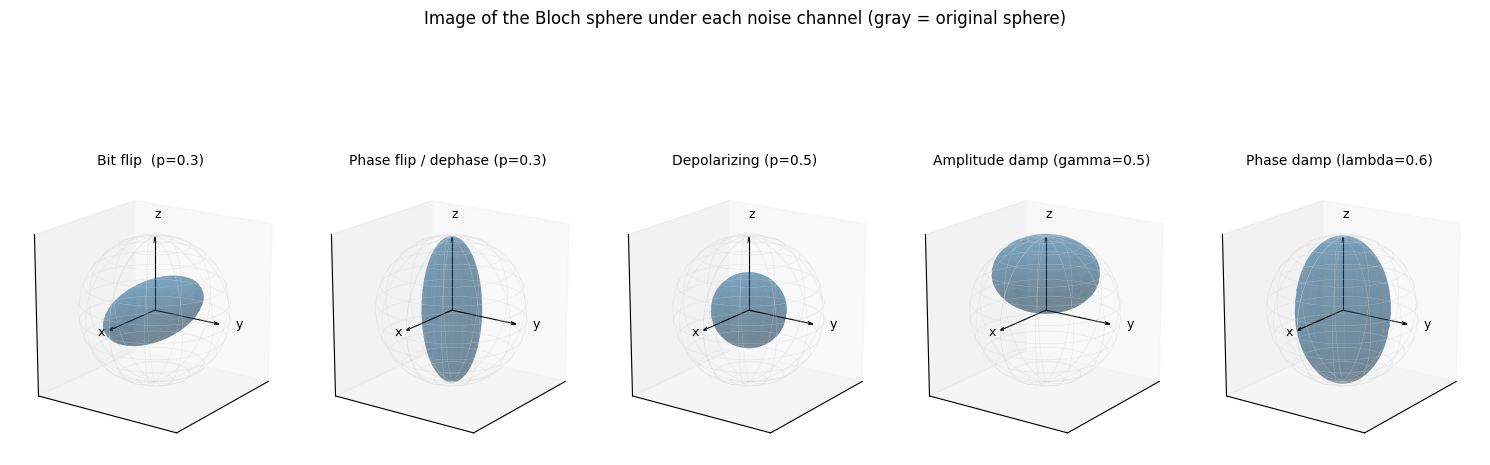

In [14]:
fig = plt.figure(figsize=(15, 6))
specs = [
    ("Bit flip  (p=0.3)",        (1, 0.4, 0.4),               (0,0,0)),
    ("Phase flip / dephase (p=0.3)", (0.4, 0.4, 1),           (0,0,0)),
    ("Depolarizing (p=0.5)",     (0.5, 0.5, 0.5),             (0,0,0)),
    ("Amplitude damp (gamma=0.5)", (np.sqrt(0.5),)*2 + (0.5,), (0,0,0.5)),
    ("Phase damp (lambda=0.6)",  (np.sqrt(0.4),)*2 + (1,),    (0,0,0)),
]
for i, (title, lam, shift) in enumerate(specs, 1):
    ax = fig.add_subplot(1, 5, i, projection='3d')
    draw_channel_image(ax, lam=lam, shift=shift, title=title)
    ax.view_init(elev=18, azim=35)
fig.suptitle("Image of the Bloch sphere under each noise channel "
             "(gray = original sphere)", y=0.98, fontsize=12)
plt.tight_layout(); plt.show()

## A.9 · Back to the core: decoherence *is* the dephasing channel

Recall the Stern–Gerlach cascade with a **which-path measurement**. Send a spin prepared as $|+\rangle_x=\tfrac1{\sqrt2}(|{\uparrow}_z\rangle+|{\downarrow}_z\rangle)$ into a region where the environment *records* which $z$-path it took. The spin alone is described by the reduced density matrix; environmental monitoring multiplies its off-diagonals by a factor that $\to 0$ as the record becomes perfect:
$$\rho_{\text{spin}}=\tfrac12\begin{pmatrix}1&1\\1&1\end{pmatrix}
\xrightarrow{\ \text{which-path}\ }
\tfrac12\begin{pmatrix}1&\kappa\\\kappa&1\end{pmatrix},\qquad \kappa\to0.$$
That is **precisely the phase-damping / dephasing channel** with $\sqrt{1-\lambda}=\kappa$. When $\kappa=0$ the alternatives are **fully distinguishable** - and the recombined beam shows **no interference**. This closes the loop on the course thesis: *indistinguishable alternatives interfere; coupling to an environment that distinguishes them is dephasing, and dephasing erases the interference.*

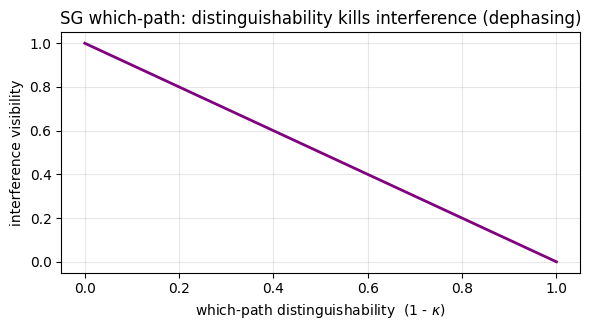

Visibility = surviving coherence kappa = sqrt(1 - lambda).
Full record (kappa=0): no fringes.  No record (kappa=1): full fringes.


In [15]:
# Interference visibility vs which-path coupling kappa = sqrt(1-lambda).
kappa = np.linspace(1, 0, 100)               # 1 = no monitoring, 0 = full record
lam   = 1 - kappa**2
# After a final 'recombination' (rotate equator coherence into a Z population),
# fringe visibility is set directly by the surviving coherence = kappa.
visibility = kappa
fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(1-kappa, visibility, lw=2, color='purple')
ax.set_xlabel("which-path distinguishability  (1 - $\\kappa$)")
ax.set_ylabel("interference visibility")
ax.set_title("SG which-path: distinguishability kills interference (dephasing)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Visibility = surviving coherence kappa = sqrt(1 - lambda).")
print("Full record (kappa=0): no fringes.  No record (kappa=1): full fringes.")

# Part B - Quantum information measures (the diagnostics)

The channels above *did* things to $\rho$. Now we build the **rulers** that quantify what they did, and show how each one answers a single plain-language question. Wherever possible we expose the **Bloch-geometric meaning**, keeping faith with the course's geometry-first style.

In [16]:
# ---- The measure toolkit (all via the spectral helpers above) --------
def von_neumann_entropy(rho, base=2):
    '''S(rho) = -Tr(rho log rho) = -sum lambda_i log lambda_i.'''
    w = eigvalsh((rho + rho.conj().T)/2)
    w = w[w > 1e-12]
    return float(max(-np.sum(w * (np.log(w)/np.log(base))), 0.0))

def relative_entropy(rho, sigma, base=2):
    '''S(rho||sigma) = Tr(rho log rho) - Tr(rho log sigma).
    Returns inf if supp(rho) is not contained in supp(sigma).'''
    ws, Vs = eigh((sigma+sigma.conj().T)/2)
    # support check: project rho onto sigma's kernel
    kernel = Vs[:, ws <= 1e-12]
    if kernel.size and np.real(np.trace(kernel.conj().T @ rho @ kernel)) > 1e-9:
        return np.inf
    val = np.trace(rho @ mlog2(rho)) - np.trace(rho @ mlog2(sigma))
    return float(np.real(val) * (np.log(2)/np.log(base)))

def fidelity(rho, sigma):
    '''Uhlmann fidelity F = (Tr sqrt(sqrt(rho) sigma sqrt(rho)))^2 in [0,1].'''
    sr = msqrt(rho)
    inner = sr @ sigma @ sr
    w = np.clip(eigvalsh((inner+inner.conj().T)/2), 0, None)
    return float(np.sum(np.sqrt(w))**2)

def trace_distance(rho, sigma):
    '''T = 1/2 Tr|rho - sigma| = 1/2 sum |eigenvalues(rho-sigma)|.'''
    w = eigvalsh(rho - sigma)
    return float(0.5*np.sum(np.abs(w)))

def l1_coherence(rho):
    '''l1-norm of coherence = sum of |off-diagonal| elements.'''
    return float(np.sum(np.abs(rho)) - np.sum(np.abs(np.diag(rho))))

def rel_entropy_coherence(rho, base=2):
    '''C_rel = S(diag(rho)) - S(rho).'''
    rho_diag = np.diag(np.diag(rho))
    return von_neumann_entropy(rho_diag, base) - von_neumann_entropy(rho, base)

print("Single-system measures ready: von_neumann_entropy, relative_entropy,")
print("fidelity, trace_distance, l1_coherence, rel_entropy_coherence.")

Single-system measures ready: von_neumann_entropy, relative_entropy,
fidelity, trace_distance, l1_coherence, rel_entropy_coherence.


In [17]:
# ---- Bipartite helpers: partial trace over 2-qubit systems -----------
def partial_trace(rho, keep, dims=(2, 2)):
    '''Partial trace of a bipartite operator.
    keep=0 -> keep subsystem A (trace out B); keep=1 -> keep B.'''
    dA, dB = dims
    R = rho.reshape(dA, dB, dA, dB)
    if keep == 0:
        return np.trace(R, axis1=1, axis2=3)      # sum over B indices
    else:
        return np.trace(R, axis1=0, axis2=2)      # sum over A indices

def mutual_information(rho_AB, base=2):
    '''I(A:B) = S(A) + S(B) - S(AB).'''
    rA = partial_trace(rho_AB, 0); rB = partial_trace(rho_AB, 1)
    return (von_neumann_entropy(rA, base) + von_neumann_entropy(rB, base)
            - von_neumann_entropy(rho_AB, base))

def conditional_entropy(rho_AB, base=2):
    '''S(A|B) = S(AB) - S(B).  Can be NEGATIVE for entangled states.'''
    rB = partial_trace(rho_AB, 1)
    return von_neumann_entropy(rho_AB, base) - von_neumann_entropy(rB, base)

def entanglement_entropy(psi_AB, base=2):
    '''For a PURE bipartite state: S of either reduced density matrix.'''
    rho = density_matrix_from_pure(psi_AB)
    return von_neumann_entropy(partial_trace(rho, 0), base)

def holevo_chi(ensemble, base=2):
    '''chi = S(sum p_i rho_i) - sum p_i S(rho_i) for ensemble [(p_i, rho_i)].'''
    avg = sum(p*r for p, r in ensemble)
    return (von_neumann_entropy(avg, base)
            - sum(p*von_neumann_entropy(r, base) for p, r in ensemble))

# Two-qubit Bell state |Phi+> = (|00> + |11>)/sqrt(2)
bell = np.zeros((4,1), dtype=complex); bell[0,0]=bell[3,0]=1/np.sqrt(2)
print("Bipartite measures ready. Partial-trace sanity check on Bell state:")
rho_bell = density_matrix_from_pure(bell)
print("rho_A = Tr_B |Phi+><Phi+| =\n", np.real(partial_trace(rho_bell, 0)),
      "  (= I/2, maximally mixed)")

Bipartite measures ready. Partial-trace sanity check on Bell state:
rho_A = Tr_B |Phi+><Phi+| =
 [[0.5 0. ]
 [0.  0.5]]   (= I/2, maximally mixed)


## B.1 · Purity - *how mixed is the state?*

$$\gamma=\operatorname{Tr}(\rho^2)\in[\tfrac1d,\,1],\qquad
\text{qubit: }\gamma=\tfrac12(1+|\mathbf r|^2).$$
$\gamma=1$ pure (surface), $\gamma=\tfrac1d$ maximally mixed (centre). Geometrically it is the **squared radius** in the Bloch ball - the single number that says how far noise has dragged you toward the centre.

In [18]:
for name, rho in [("|0>", density_matrix_from_pure(ket0)),
                  ("|+>", rho_plus),
                  ("dephased |+> (p=0.5)", apply_kraus(rho_plus, phase_flip_kraus(0.5))),
                  ("I/2", I2/2)]:
    r = bloch_from_rho(rho)
    print(f"{name:24s} purity={purity(rho):.3f}  |r|^2={np.dot(r,r):.3f}  "
          f"check 1/2(1+|r|^2)={0.5*(1+np.dot(r,r)):.3f}")

|0>                      purity=1.000  |r|^2=1.000  check 1/2(1+|r|^2)=1.000
|+>                      purity=1.000  |r|^2=1.000  check 1/2(1+|r|^2)=1.000
dephased |+> (p=0.5)     purity=0.500  |r|^2=0.000  check 1/2(1+|r|^2)=0.500
I/2                      purity=0.500  |r|^2=0.000  check 1/2(1+|r|^2)=0.500


## B.2 · von Neumann entropy - *how much uncertainty / missing information?*

$$S(\rho)=-\operatorname{Tr}(\rho\log_2\rho)=-\sum_i\lambda_i\log_2\lambda_i,$$
the quantum Shannon entropy of the **eigenvalues** of $\rho$. $S=0$ for any pure state (you know it completely); $S=\log_2 d=1$ bit for a maximally mixed qubit. For a qubit it is the **binary entropy of $(1\pm|\mathbf r|)/2$** - another pure function of the Bloch radius. Purity and entropy are two readings of the same dial: as a channel shrinks $|\mathbf r|$, $\gamma$ falls and $S$ rises.

In [19]:
def binary_entropy(q):
    if q in (0,1): return 0.0
    return -(q*np.log2(q) + (1-q)*np.log2(1-q))

print(f"{'state':24s}{'S(rho) [bits]':>15s}{'binary-entropy check':>24s}")
for name, rho in [("|0>", density_matrix_from_pure(ket0)),
                  ("dephased |+> (p=0.25)", apply_kraus(rho_plus, phase_flip_kraus(0.25))),
                  ("depolarized |+> (p=0.6)", apply_kraus(rho_plus, depolarizing_kraus(0.6))),
                  ("I/2", I2/2)]:
    r = bloch_from_rho(rho); rad = np.linalg.norm(r)
    print(f"{name:24s}{von_neumann_entropy(rho):15.3f}"
          f"{binary_entropy((1+rad)/2):24.3f}")

state                     S(rho) [bits]    binary-entropy check
|0>                              -0.000                   0.000
dephased |+> (p=0.25)             0.811                   0.811
depolarized |+> (p=0.6)           0.881                   0.881
I/2                               1.000                   1.000


## B.3 · Relative entropy - *how distinguishable are two states?* (asymmetric)

$$S(\rho\,\|\,\sigma)=\operatorname{Tr}\rho\log_2\rho-\operatorname{Tr}\rho\log_2\sigma\ \ge 0,$$
the quantum **Kullback–Leibler divergence**. It is $0$ iff $\rho=\sigma$ (Klein's inequality), **not symmetric**, and **$+\infty$** when $\rho$ has support where $\sigma$ does not (an outcome certain under $\rho$ but impossible under $\sigma$ instantly betrays the difference). It is the parent quantity behind coherence, mutual information and the Holevo bound - all are relative entropies in disguise.

In [20]:
rho_a = rho_from_bloch([0.0, 0.0, 0.6])
rho_b = rho_from_bloch([0.0, 0.0, 0.2])
print("S(a||b) =", round(relative_entropy(rho_a, rho_b), 4))
print("S(b||a) =", round(relative_entropy(rho_b, rho_a), 4), " (asymmetry!)")
print("S(a||a) =", round(relative_entropy(rho_a, rho_a), 4), " (=0)")
print("S(|0><0| || |1><1|) =",
      relative_entropy(density_matrix_from_pure(ket0),
                       density_matrix_from_pure(ket1)), " (support mismatch -> inf)")

S(a||b) = 0.132
S(b||a) = 0.151  (asymmetry!)
S(a||a) = 0.0  (=0)
S(|0><0| || |1><1|) = inf  (support mismatch -> inf)


## B.4 · Fidelity & trace distance - *how similar / how distinguishable?*

**Fidelity** $F(\rho,\sigma)=\big(\operatorname{Tr}\sqrt{\sqrt\rho\,\sigma\sqrt\rho}\big)^2\in[0,1]$, symmetric, $=1$ iff equal; for pure states $F=|\langle\psi|\phi\rangle|^2$, and for one pure state $F=\langle\psi|\sigma|\psi\rangle$.

**Trace distance** $T(\rho,\sigma)=\tfrac12\operatorname{Tr}|\rho-\sigma|$ is a *true metric* with a sharp operational meaning: the **best possible single-shot probability of telling the two states apart** is $\tfrac12\big(1+T\big)$ (Helstrom). For qubits it is breathtakingly simple,
$$\boxed{\,T(\rho,\sigma)=\tfrac12\,|\mathbf r_\rho-\mathbf r_\sigma|\,}$$
- *half the Euclidean distance between Bloch vectors*. The two measures bracket each other: $1-\sqrt F\le T\le\sqrt{1-F}$.

In [21]:
rho_p = rho_plus
rho_m = density_matrix_from_pure(minus)
print("F(|+>,|->) =", round(fidelity(rho_p, rho_m), 4), " (orthogonal -> 0)")
print("T(|+>,|->) =", round(trace_distance(rho_p, rho_m), 4), " (antipodal -> 1)")
print("Best single-shot discrimination prob =",
      round(0.5*(1+trace_distance(rho_p, rho_m)), 4))

# qubit trace-distance = half Bloch-vector distance
a = rho_from_bloch([0.3, 0.1, 0.5]); b = rho_from_bloch([-0.2, 0.4, 0.1])
ra, rb = bloch_from_rho(a), bloch_from_rho(b)
print("\nT(a,b)            =", round(trace_distance(a, b), 4))
print("1/2 |r_a - r_b|   =", round(0.5*np.linalg.norm(ra-rb), 4))

# Fidelity-trace-distance bounds
F = fidelity(a, b); T = trace_distance(a, b)
print(f"\nBounds check: 1-sqrt(F)={1-np.sqrt(F):.3f} <= T={T:.3f} "
      f"<= sqrt(1-F)={np.sqrt(1-F):.3f}")

F(|+>,|->) = 0.0  (orthogonal -> 0)
T(|+>,|->) = 1.0  (antipodal -> 1)
Best single-shot discrimination prob = 1.0

T(a,b)            = 0.3536
1/2 |r_a - r_b|   = 0.3536

Bounds check: 1-sqrt(F)=0.065 <= T=0.354 <= sqrt(1-F)=0.356


## B.5 · Coherence measures - *how much superposition (in a chosen basis)?*

Coherence is **basis-dependent** - it lives in the *off-diagonal* elements relative to a fixed reference basis (here the computational $Z$-basis).

- **$\ell_1$-norm of coherence:** $C_{\ell_1}(\rho)=\sum_{i\ne j}|\rho_{ij}|$. For a qubit, $C_{\ell_1}=2|\rho_{01}|=\sqrt{r_x^2+r_y^2}$ - exactly the **equatorial (transverse) length** of the Bloch vector.
- **Relative entropy of coherence:** $C_{\text{rel}}(\rho)=S(\rho_{\text{diag}})-S(\rho)$, the entropy you "pay" by erasing the off-diagonals.

Dephasing is, by definition, the channel that **destroys coherence** - watch both measures track the equator collapsing.

In [22]:
print(f"{'state':28s}{'C_l1':>8s}{'sqrt(rx^2+ry^2)':>18s}{'C_rel':>8s}")
for p in [0.0, 0.25, 0.5]:
    rp = apply_kraus(rho_plus, phase_flip_kraus(p))
    r = bloch_from_rho(rp)
    print(f"dephased |+>  p={p:<14.2f}{l1_coherence(rp):8.3f}"
          f"{np.hypot(r[0], r[1]):18.3f}{rel_entropy_coherence(rp):8.3f}")
print("\n|0> (a Z-basis state) has zero coherence:",
      round(l1_coherence(density_matrix_from_pure(ket0)), 4))

state                           C_l1   sqrt(rx^2+ry^2)   C_rel
dephased |+>  p=0.00             1.000             1.000   1.000
dephased |+>  p=0.25             0.500             0.500   0.189
dephased |+>  p=0.50             0.000             0.000   0.000

|0> (a Z-basis state) has zero coherence: 0.0


## B.6 · Going bipartite: reduced states and the Bell resource

For two qubits $AB$, tracing out one subsystem gives the **reduced density matrix** $\rho_A=\operatorname{Tr}_B\rho_{AB}$. The remaining measures compare the whole to its parts. Our running example is the **Bell state** $|\Phi^+\rangle=\tfrac1{\sqrt2}(|00\rangle+|11\rangle)$, whose reduced state is maximally mixed - *the global state is pure and perfectly known, yet each half is maximally uncertain*. That tension is the signature of entanglement, and the next four measures quantify it.

In [23]:
rho_bell = density_matrix_from_pure(bell)
rA = partial_trace(rho_bell, 0); rB = partial_trace(rho_bell, 1)
print("Global purity Tr(rho_AB^2) =", round(purity(rho_bell), 3), " (pure)")
print("S(AB) =", round(von_neumann_entropy(rho_bell), 3), " bits  (whole is certain)")
print("S(A)  =", round(von_neumann_entropy(rA), 3),
      " bits  (each half is maximally uncertain)")
# A product (separable) state for contrast:
prod = np.kron(plus, ket0)
rho_prod = density_matrix_from_pure(prod)
print("\nProduct |+>|0|:  S(A)=", round(von_neumann_entropy(partial_trace(rho_prod,0)),3),
      " S(AB)=", round(von_neumann_entropy(rho_prod),3))

Global purity Tr(rho_AB^2) = 1.0  (pure)
S(AB) = 0.0  bits  (whole is certain)
S(A)  = 1.0  bits  (each half is maximally uncertain)

Product |+>|0|:  S(A)= 0.0  S(AB)= 0.0


## B.7 · Mutual information - *how much total correlation is shared?*

$$I(A\!:\!B)=S(A)+S(B)-S(AB)\ \ge 0.$$
It captures **all** correlations - classical *and* quantum. For a **pure** bipartite state it equals **twice** the entanglement entropy, $I(A\!:\!B)=2\,S(A)$. A maximally entangled Bell pair therefore shares $2$ bits of mutual information while either half alone carries only $1$ bit of entropy - the extra bit is the purely-quantum correlation.

In [24]:
print("Bell  |Phi+> :  I(A:B) =", round(mutual_information(rho_bell), 3),
      " bits  ( = 2 * S(A) =", round(2*von_neumann_entropy(rA), 3), ")")
print("Product|+>|0|:  I(A:B) =", round(mutual_information(rho_prod), 3),
      " bits  (uncorrelated)")
# A classically-correlated mixture (no entanglement) for contrast:
rho_cc = 0.5*(density_matrix_from_pure(np.kron(ket0,ket0))
              + density_matrix_from_pure(np.kron(ket1,ket1)))
print("Classical corr:  I(A:B) =", round(mutual_information(rho_cc), 3),
      " bits  (1 bit of *classical* correlation)")

Bell  |Phi+> :  I(A:B) = 2.0  bits  ( = 2 * S(A) = 2.0 )
Product|+>|0|:  I(A:B) = 0.0  bits  (uncorrelated)
Classical corr:  I(A:B) = 1.0  bits  (1 bit of *classical* correlation)


## B.8 · Conditional entropy - *how uncertain is $A$ given $B$?* (and its quantum negativity)

$$S(A|B)=S(AB)-S(B).$$
Classically conditional entropy is **never negative** - knowing $B$ cannot make you *more* than certain about $A$. Quantum mechanically it **can go negative**, and that negativity is a *direct fingerprint of entanglement*. For a Bell pair $S(A|B)=0-1=-1$ bit. The operational reading (state-merging) is striking: negative conditional entropy is **distributed entanglement banked for future use** - the parties end up *owing* negative information, i.e. holding spare entanglement.

In [25]:
print("Bell  |Phi+> :  S(A|B) =", round(conditional_entropy(rho_bell), 3),
      " bits  (NEGATIVE -> entangled)")
print("Product|+>|0|:  S(A|B) =", round(conditional_entropy(rho_prod), 3), " bits")
print("Classical corr:  S(A|B) =", round(conditional_entropy(rho_cc), 3),
      " bits  (>=0, classical)")
# Coherent information I(A>B) = -S(A|B) - the quantum-channel-capacity quantity
print("\nCoherent information I(A>B) = -S(A|B) for Bell =",
      round(-conditional_entropy(rho_bell), 3), " bits")

Bell  |Phi+> :  S(A|B) = -1.0  bits  (NEGATIVE -> entangled)
Product|+>|0|:  S(A|B) = 0.0  bits
Classical corr:  S(A|B) = 0.0  bits  (>=0, classical)

Coherent information I(A>B) = -S(A|B) for Bell = 1.0  bits


## B.9 · Entanglement entropy - *how much entanglement (pure states)?*

For a **pure** bipartite state, the entanglement is measured by the von Neumann entropy of either reduced state,
$$E(|\psi\rangle_{AB})=S(\rho_A)=S(\rho_B).$$
$0$ for a product state, $1$ bit (an *ebit*) for a Bell pair. It equals the entropy of the **Schmidt coefficients**. (For *mixed* states this single number is no longer enough; one needs entanglement of formation, negativity, etc. - flagged in the exercises.)

In [26]:
# Tunable entanglement: |psi> = cos(t)|00> + sin(t)|11>
print(f"{'theta':>8s}{'E (ebits)':>12s}")
for theta in [0, np.pi/8, np.pi/4]:
    psi = np.zeros((4,1), dtype=complex)
    psi[0,0]=np.cos(theta); psi[3,0]=np.sin(theta)
    print(f"{theta:8.3f}{entanglement_entropy(psi):12.3f}")
print("theta=pi/4 is the Bell state -> 1 ebit (maximal).")

   theta   E (ebits)
   0.000      -0.000
   0.393       0.601
   0.785       1.000
theta=pi/4 is the Bell state -> 1 ebit (maximal).


## B.10 · Holevo quantity - *how much classical information can you read out?*

Given an ensemble $\{p_i,\rho_i\}$ (a classical message $i$ encoded into quantum states), the **accessible information** - what any measurement can recover about $i$ - is bounded by the **Holevo $\chi$**:
$$I(X\!:\!Y)\le\chi=S\!\Big(\sum_i p_i\rho_i\Big)-\sum_i p_i\,S(\rho_i).$$
$\chi\le\log_2 d$, which is **why $n$ qubits cannot reliably deliver more than $n$ classical bits** despite living in a continuous $2^n$-dimensional space. With **orthogonal** signal states $\chi$ saturates $\log_2 d$ (perfectly readable); with **non-orthogonal** states $\chi$ drops - the overlap is information you can never fully extract.

Orthogonal signals {|0>,|1>}      : chi = 1.0  bit  (= log2 2, fully readable)
Non-orthogonal {|0>,|+>}          : chi = 0.601  bit  (< 1, overlap hides info)


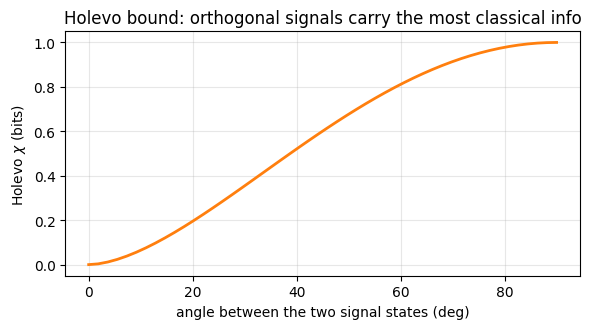

In [27]:
def chi_for(states):
    return holevo_chi([(0.5, density_matrix_from_pure(s)) for s in states])

print("Orthogonal signals {|0>,|1>}      : chi =",
      round(chi_for([ket0, ket1]), 3), " bit  (= log2 2, fully readable)")
print("Non-orthogonal {|0>,|+>}          : chi =",
      round(chi_for([ket0, plus]), 3), " bit  (< 1, overlap hides info)")
# sweep overlap
angles = np.linspace(0, np.pi/2, 50)
chis = [chi_for([ket0, np.cos(a)*ket0 + np.sin(a)*ket1]) for a in angles]
fig, ax = plt.subplots(figsize=(6,3.4))
ax.plot(np.degrees(angles), chis, lw=2, color='tab:orange')
ax.set_xlabel("angle between the two signal states (deg)")
ax.set_ylabel(r"Holevo $\chi$ (bits)")
ax.set_title("Holevo bound: orthogonal signals carry the most classical info")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## B.11 · Synthesis -  The diagnostics (quantifiers) reading the dephasing channel

Everything now comes together. Drive $|+\rangle$ through increasing **dephasing** and track four measures at once. Purity and coherence fall, entropy rises, and the trace distance from the original pure state grows - *the noise channel of Part A, fully characterised by the rulers of Part B.*

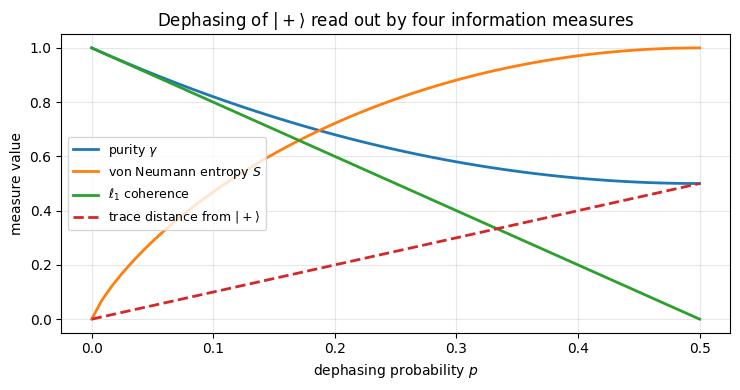

At p=0.5: pure superposition |+> has become the classical mixture I/2.


In [28]:
ps = np.linspace(0, 0.5, 60)
rho0 = rho_plus
pur, ent, coh, td = [], [], [], []
for p in ps:
    rp = apply_kraus(rho0, phase_flip_kraus(p))
    pur.append(purity(rp))
    ent.append(von_neumann_entropy(rp))
    coh.append(l1_coherence(rp))
    td.append(trace_distance(rho0, rp))

fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(ps, pur, lw=2, label="purity $\\gamma$")
ax.plot(ps, ent, lw=2, label="von Neumann entropy $S$")
ax.plot(ps, coh, lw=2, label="$\\ell_1$ coherence")
ax.plot(ps, td,  lw=2, ls='--', label="trace distance from $|+\\rangle$")
ax.set_xlabel("dephasing probability $p$")
ax.set_ylabel("measure value")
ax.set_title("Dephasing of $|+\\rangle$ read out by four information measures")
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("At p=0.5: pure superposition |+> has become the classical mixture I/2.")

## B.12 · Interactive explorer (live Colab)

An `ipywidgets` panel to dial any channel and read every measure instantly.

In [29]:
def channel_report(channel="dephasing", strength=0.3):
    chans = {
        "bit_flip":      bit_flip_kraus,
        "phase_flip":    phase_flip_kraus,
        "depolarizing":  depolarizing_kraus,
        "amplitude_damp":amplitude_damping_kraus,
        "phase_damp":    phase_damping_kraus,
        "dephasing":     phase_flip_kraus,
    }
    rho = apply_kraus(rho_plus, chans[channel](strength))
    r = bloch_from_rho(rho)
    print(f"channel = {channel},  strength = {strength}")
    print(f"  Bloch r         = {np.round(r,3)}")
    print(f"  purity          = {purity(rho):.3f}")
    print(f"  von Neumann S   = {von_neumann_entropy(rho):.3f} bits")
    print(f"  l1 coherence    = {l1_coherence(rho):.3f}")
    print(f"  trace dist |+>  = {trace_distance(rho_plus, rho):.3f}")
    print(f"  fidelity to |+> = {fidelity(rho_plus, rho):.3f}")

try:
    from ipywidgets import interact, FloatSlider, Dropdown
    interact(channel_report,
             channel=Dropdown(options=["bit_flip","phase_flip","depolarizing",
                                       "amplitude_damp","phase_damp","dephasing"],
                              value="dephasing"),
             strength=FloatSlider(min=0, max=1, step=0.05, value=0.3))
except Exception as e:
    print("[Static fallback - live widgets appear in Colab]\n")
    channel_report("dephasing", 0.3)
    print()
    channel_report("amplitude_damp", 0.5)

interactive(children=(Dropdown(description='channel', index=5, options=('bit_flip', 'phase_flip', 'depolarizin…

## B.13 · One-screen reference

| Measure | Question it answers | Formula | Bloch / key fact |
|---|---|---|---|
| Purity $\gamma$ | How mixed? | $\operatorname{Tr}\rho^2$ | $\tfrac12(1+|\mathbf r|^2)$ |
| von Neumann $S$ | How uncertain? | $-\operatorname{Tr}\rho\log\rho$ | binary entropy of $(1\pm|\mathbf r|)/2$ |
| Relative entropy | How distinguishable? (asym.) | $\operatorname{Tr}\rho(\log\rho-\log\sigma)$ | $\ge0$, can be $\infty$ |
| Fidelity $F$ | How similar? | $(\operatorname{Tr}\sqrt{\sqrt\rho\,\sigma\sqrt\rho})^2$ | $=|\langle\psi|\phi\rangle|^2$ (pure) |
| Trace distance $T$ | Single-shot distinguishability | $\tfrac12\operatorname{Tr}|\rho-\sigma|$ | $\tfrac12|\mathbf r_\rho-\mathbf r_\sigma|$; $P_{\text{disc}}=\tfrac12(1+T)$ |
| $\ell_1$ coherence | How much superposition? | $\sum_{i\ne j}|\rho_{ij}|$ | $\sqrt{r_x^2+r_y^2}$ (equator) |
| Mutual info $I(A\!:\!B)$ | Total shared info | $S_A+S_B-S_{AB}$ | $=2S_A$ for pure |
| Conditional $S(A|B)$ | Residual uncertainty | $S_{AB}-S_B$ | **negative $\Rightarrow$ entangled** |
| Entanglement entropy | Pure-state entanglement | $S(\rho_A)$ | $1$ ebit for Bell |
| Holevo $\chi$ | Extractable classical info | $S(\bar\rho)-\sum p_iS(\rho_i)$ | $\le\log_2 d$ |


## Exercises (★ – ★★★)

Solutions are collapsed; try first, then run the solution cell.

**★ 1.** Verify numerically that the depolarizing channel leaves the *direction* of $\mathbf r$ unchanged while scaling its length by $(1-p)$. Pick three random Bloch vectors.

**★ 2.** For $|0\rangle$ passed through amplitude damping with $\gamma=0.3$, compute purity, $S$, and the excited-state population. Explain why $|0\rangle$ is unchanged.

**★★ 3.** Confirm the bound $1-\sqrt F\le T\le\sqrt{1-F}$ for 20 random qubit pairs.

**★★ 4.** Build the maximally coherent state in the $X$-basis and show it has **zero** $\ell_1$-coherence in the $X$-basis but maximal coherence in the $Z$-basis - making the point that coherence is basis-relative.

**★★★ 5.** Take the state $\cos\theta|00\rangle+\sin\theta|11\rangle$. Plot entanglement entropy, mutual information and conditional entropy versus $\theta\in[0,\pi/2]$ on one axis, and verify $I=2E$ and $S(A|B)=-E$ throughout.

**★★★ 6.** *Channel that beats the Holevo bound?* Encode 2 classical bits into the 4 BB84 states $\{|0\rangle,|1\rangle,|+\rangle,|-\rangle\}$ with equal priors and compute $\chi$. Why is it **below** 1 bit, and what does that say about cloning / eavesdropping?

In [30]:
# ===== Solutions (run to check) =====

# --- Solution 1 (star) ---
print("Solution 1:")
for _ in range(3):
    r = np.random.uniform(-0.5, 0.5, 3)
    out = bloch_from_rho(apply_kraus(rho_from_bloch(r), depolarizing_kraus(0.4)))
    ratio = out / r
    print(f"  r={np.round(r,3)}  ratios r'/r={np.round(ratio,3)} (all = 1-p = 0.6)")

# --- Solution 2 (star) ---
print("\nSolution 2:")
r0 = density_matrix_from_pure(ket0)
rg = apply_kraus(r0, amplitude_damping_kraus(0.3))
print(f"  |0> after AD(0.3): purity={purity(rg):.3f}, S={von_neumann_entropy(rg):.3f}, "
      f"P(1)={born_probs(rg)[1]:.3f}")
print("  |0> is the fixed point (ground state): nothing to decay, so it is unchanged.")

# --- Solution 3 (star star) ---
print("\nSolution 3:")
ok = True
for _ in range(20):
    a = rho_from_bloch(np.random.uniform(-0.6,0.6,3))
    b = rho_from_bloch(np.random.uniform(-0.6,0.6,3))
    F, T = fidelity(a,b), trace_distance(a,b)
    if not (1-np.sqrt(F) - 1e-9 <= T <= np.sqrt(1-F) + 1e-9): ok = False
print("  all 20 pairs satisfy 1-sqrt(F) <= T <= sqrt(1-F):", ok)

Solution 1:
  r=[-0.125  0.451  0.232]  ratios r'/r=[0.6 0.6 0.6] (all = 1-p = 0.6)
  r=[ 0.099 -0.344 -0.344]  ratios r'/r=[0.6 0.6 0.6] (all = 1-p = 0.6)
  r=[-0.442  0.366  0.101]  ratios r'/r=[0.6 0.6 0.6] (all = 1-p = 0.6)

Solution 2:
  |0> after AD(0.3): purity=1.000, S=-0.000, P(1)=0.000
  |0> is the fixed point (ground state): nothing to decay, so it is unchanged.

Solution 3:
  all 20 pairs satisfy 1-sqrt(F) <= T <= sqrt(1-F): True


Solution 4:
  l1-coherence of |0> in Z-basis: 0.0  (Z eigenstate -> none)
  l1-coherence of |0> in X-basis: 1.0  (= (|+>+|->)/sqrt2 -> maximal)
  Lesson: coherence is a property of the state RELATIVE to a chosen basis.

Solution 5:
  max|I - 2E|     = 0.0  (-> I = 2E)
  max|S(A|B) + E| = 0.0  (-> S(A|B) = -E)


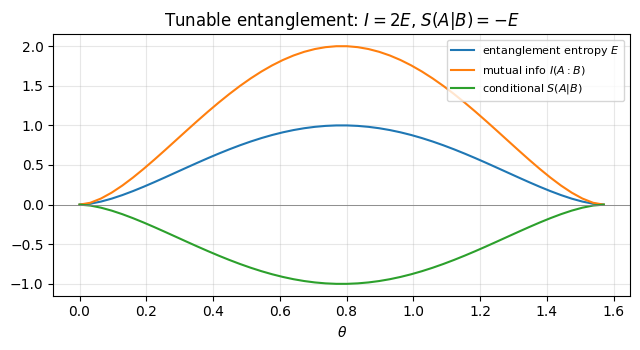

Solution 6:
  BB84 four-state ensemble: chi = 1.000 bit
  Two 'bits' worth of state-labels are encoded, but chi caps the extractable
  classical information at 1 bit (the ensemble average is I/2, S=1).
  No single measurement reveals the basis -- the very fact that protects BB84:
  an eavesdropper cannot read both bases, and cloning is forbidden.


In [31]:
# --- Solution 4 (star star) ---
print("Solution 4:")
# |0> is a Z-basis eigenstate: diagonal in Z (no coherence), but in the X-basis
# it is the equal superposition (|+>+|->)/sqrt2 -> maximally coherent.
rho0 = density_matrix_from_pure(ket0)
Hd = (X+Z)/np.sqrt(2)                       # Hadamard maps X-basis <-> Z-basis
rho0_xbasis = Hd @ rho0 @ Hd.conj().T       # |0> expressed in the X-basis
print("  l1-coherence of |0> in Z-basis:", round(l1_coherence(rho0), 3),
      " (Z eigenstate -> none)")
print("  l1-coherence of |0> in X-basis:", round(l1_coherence(rho0_xbasis), 3),
      " (= (|+>+|->)/sqrt2 -> maximal)")
print("  Lesson: coherence is a property of the state RELATIVE to a chosen basis.")

# --- Solution 5 (star star star) ---
print("\nSolution 5:")
thetas = np.linspace(0, np.pi/2, 50)
E, Ifo, cond = [], [], []
for t in thetas:
    psi = np.zeros((4,1), dtype=complex); psi[0,0]=np.cos(t); psi[3,0]=np.sin(t)
    rho = density_matrix_from_pure(psi)
    E.append(entanglement_entropy(psi))
    Ifo.append(mutual_information(rho))
    cond.append(conditional_entropy(rho))
E, Ifo, cond = map(np.array, (E, Ifo, cond))
print("  max|I - 2E|     =", round(np.max(np.abs(Ifo - 2*E)), 6), " (-> I = 2E)")
print("  max|S(A|B) + E| =", round(np.max(np.abs(cond + E)), 6), " (-> S(A|B) = -E)")
fig, ax = plt.subplots(figsize=(6.5,3.6))
ax.plot(thetas, E,   label="entanglement entropy $E$")
ax.plot(thetas, Ifo, label="mutual info $I(A{:}B)$")
ax.plot(thetas, cond,label="conditional $S(A|B)$")
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel(r"$\theta$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title("Tunable entanglement: $I=2E$, $S(A|B)=-E$")
plt.tight_layout(); plt.show()

# --- Solution 6 (star star star) ---
print("Solution 6:")
bb84 = [ket0, ket1, plus, minus]
chi = holevo_chi([(0.25, density_matrix_from_pure(s)) for s in bb84])
print(f"  BB84 four-state ensemble: chi = {chi:.3f} bit")
print("  Two 'bits' worth of state-labels are encoded, but chi caps the extractable")
print("  classical information at 1 bit (the ensemble average is I/2, S=1).")
print("  No single measurement reveals the basis -- the very fact that protects BB84:")
print("  an eavesdropper cannot read both bases, and cloning is forbidden.")

## Where this connects, and what's next

**Carried forward unchanged** into any later notebook: `rho_from_bloch`, `bloch_from_rho`, `purity`, `apply_kraus`, all five channel constructors, and the full measure toolkit (`von_neumann_entropy`, `fidelity`, `trace_distance`, `mutual_information`, `conditional_entropy`, `entanglement_entropy`, `holevo_chi`, …).

**Natural next steps on the course roadmap**
- **CHSH / Bell inequality** notebook - conditional-entropy negativity and mutual information are the bridge to nonlocality.
- **Teleportation & superdense coding** - both are accounting exercises in the ebits and Holevo bits defined here.
- **Quantum error correction** - the depolarizing channel and the Pauli-error picture are exactly the noise model the 3-qubit and surface codes are designed to beat.
- **Mixed-state entanglement** - negativity / logarithmic negativity and entanglement of formation, to handle the cases where entanglement entropy alone is insufficient.

> **The one-line takeaway for faculty:** *Noise channels move the Bloch vector; information measures read its new position. Decoherence is the dephasing channel, and that is precisely why distinguishable which-path alternatives stop interfering.*
